In [1]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam import GradCAM

import torch
import numpy as np
from PIL import Image
import torchvision
from torchvision import datasets, models, transforms
from train import *
from glob import glob

In [2]:
from datapipe import WGM_dataset
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam import GradCAM

In [3]:
TRAIN_CSV_PATH = "/home/mahirwar/Desktop/Monika/npsad_data/monika/LBD/Intermediate_data/train_redmarked.csv"
VAL_CSV_PATH = "/home/mahirwar/Desktop/Monika/npsad_data/monika/LBD/Intermediate_data/val_redmarked.csv"

In [4]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(1024),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        #transforms.FiveCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.8965, 0.8875, 0.9023],[0.0807, 0.0911, 0.0849])
        #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(1024),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.8965, 0.8875, 0.9023],[0.0807, 0.0911, 0.0849])
       # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        #transforms.Resize(256),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.8965, 0.8875, 0.9023],[0.0807, 0.0911, 0.0849])
        #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

batch_size = 16

In [5]:
train_wgm = WGM_dataset(TRAIN_CSV_PATH, data_transforms, "train", batch_size)
val_wgm = WGM_dataset(VAL_CSV_PATH, data_transforms, "val", batch_size)

In [6]:
train_loader = train_wgm.build_data_pipe()
val_loader = val_wgm.build_data_pipe()
dataloaders = {"train":train_loader, "val": val_loader}
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

train_datasize = train_wgm.dataset_size()
val_datasize = val_wgm.dataset_size()
dataset_sizes = {'train':train_datasize, 'val':val_datasize}

In [7]:
dataloaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x7f9a3c7a33d0>,
 'val': <torch.utils.data.dataloader.DataLoader at 0x7f9a3c7a36d0>}

In [8]:
dataset_sizes

{'train': 172789, 'val': 76791}

In [9]:
path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/221kusfe-logs.pth'
model_ft = load_saved_model(path)

In [10]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.squeeze()
    print(inp.shape)
    #inp = inp.numpy().transpose((0, 3, 2, 1))
    inp = inp.numpy().transpose((1, 2, 0))
    
    print(inp.shape)
    mean = np.array([0.8965, 0.8875, 0.9023])
    std = np.array([0.0807, 0.0911, 0.0849])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated
    
def save_image(input_tensor, path, name):
    inp = input_tensor.squeeze(0)
    print(inp.shape)
    #inp = inp.numpy().transpose((0, 3, 2, 1))
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    print(inp.shape)
    mean = np.array([0.8965, 0.8875, 0.9023])
    std = np.array([0.0807, 0.0911, 0.0849])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    img = Image.fromarray((inp* 255).astype(np.uint8))
    img.save(os.path.join(path, name + ".png"))
    return img


def visualize_model(model):
    was_training = model.training
    model.eval()
    actual_labels = []
    pred_labels = []
    wsi_names = []
    scores=[]
    act_white_labeled_gray = []
    act_gray_labeled_white = []
    imgs = []
    c1=0
    c2=0
    for i, (wsi, inputs, labels) in enumerate(dataloaders['val']):
        #print("-------------------",i,"--------------------")
        inputs=inputs.squeeze()
        labels = labels.squeeze()
        inputs = inputs.to(device)
        labels = labels.to(device)
        actual_labels = labels.tolist()
        outputs = model(inputs)
        scores.extend(outputs.cpu().tolist())
        _, preds = torch.max(outputs, 1)
        pred_labels = preds.tolist()
        wsi=[x[0] for x in wsi]
        #wsi_names.extend(wsi)
        if c1>=5:
            break
        for j in range(len(labels)):
            if (actual_labels[j]==0) and (pred_labels[j]==0):
                img = save_image(inputs[j],"/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/pred_g_act_g", wsi[0]+"_"+str(i)+"_"+str(j))
                imgs.append(img)
                c1=c1+1
    return c1, imgs

def gradcam(model_ft, image_path):
    img = Image.open(image_path)
    img = np.array(img)/255
    tr = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.8965, 0.8875, 0.9023],[0.0807, 0.0911, 0.0849])])
    target_layers = [model_ft.layer4[-1]]
    cam = GradCAM(model=model_ft, target_layers=target_layers, use_cuda=True)
    input_tensor = tr(img).to(device, dtype=torch.float)
    grayscale_cam = cam(input_tensor=input_tensor.unsqueeze(0))
    grayscale_cam = grayscale_cam[0, :]
    visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)     
    plt.imshow(Image.fromarray(visualization, 'RGB'))
    

In [52]:
image_path = glob(os.path.join("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/pred_w_act_w","*.png"))
#for im in image_path:

In [53]:
image_path

['/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/pred_w_act_w/3.png',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/pred_w_act_w/4.png',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/pred_w_act_w/2.png',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/pred_w_act_w/1.png',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/pred_w_act_w/3_gc.png',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/pred_w_act_w/1_gc.png',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/pred_w_act_w/5_gc.png',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/pred_w_act_w/2_gc.png',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/pred_w_act_w/5.png',
 '/gladstone/finkbeiner/steve/work/data/npsad_data/m

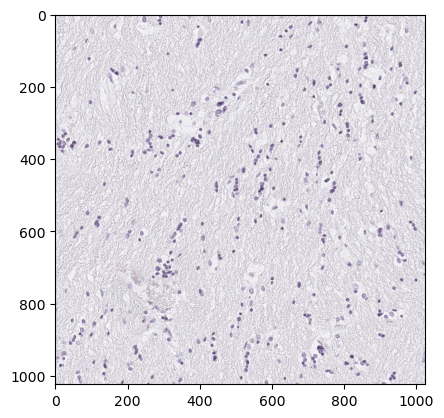

In [106]:
im = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/w_act_pred_gray/5.png"
plt.imshow(Image.open(im))

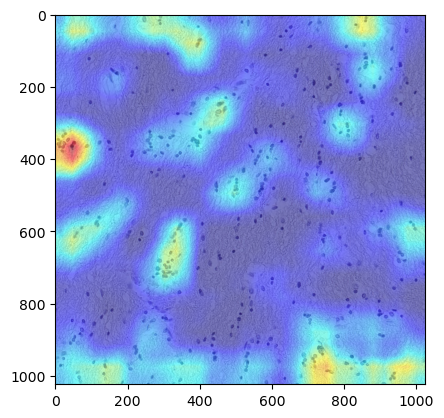

: 

In [107]:
#im = image_path[4]
gradcam(model_ft, im)

In [13]:
#counter, imgs = visualize_model(model_ft)